# 06 · Stacking Ensemble

**Objetivo:** combinar LightGBM, XGBoost y Random Forest en un ensemble de stacking
que supere al mejor modelo individual.

### ¿Por qué stacking y no averaging?
- **Averaging**: simplemente promediar las probabilidades de los modelos → fácil pero subóptimo
- **Stacking**: un meta-modelo aprende *cómo combinar* las predicciones de los base learners
  → puede aprender que "cuando LGBM y RF coinciden pero XGB discrepa, confiar en la mayoría"

```
Nivel 0 (base learners)          Nivel 1 (meta-modelo)
──────────────────────           ─────────────────────
LightGBM  ──┐
XGBoost   ──┼─→  probabilidades  →  LogisticRegression  →  predicción final
RandomForest┘
```

### ¿Por qué Regresión Logística como meta-modelo?
- Simple, regularizada, interpretable (sus coeficientes son el "peso" de cada base learner)
- No sobreajusta con solo 3 features de entrada (las 3 probabilidades)
- Con `class_weight='balanced'` mantiene el sesgo hacia la clase fallo

### Clave técnica: out-of-fold predictions
`StackingClassifier` genera las predicciones de nivel 0 mediante cross-validation:
cada base learner predice sobre datos que NO vio en entrenamiento.
Esto evita que el meta-modelo aprenda de predicciones "trampa" (overfitted al train).

In [1]:
import sys; sys.path.insert(0, '../src')
import pickle
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)
from utils import eval_threshold   # función compartida en src/utils.py

with open('../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../data/processed/models.pkl', 'rb') as f:
    models = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print('Train:', X_train.shape, '| Fallos train:', y_train.sum())
print('Test: ', X_test.shape,  '| Fallos test: ', y_test.sum())


Train: (8000, 10) | Fallos train: 271
Test:  (2000, 10) | Fallos test:  68


## 1. Definir base learners

Usamos **instancias nuevas** de cada modelo (no los modelos guardados en pkl).

**¿Por qué instancias nuevas?**
`StackingClassifier` reentrena internamente cada base learner con cross-val out-of-fold.
Si usáramos los modelos ya entrenados, las predicciones de nivel 0 serían "trampa"
(generadas con datos que el modelo ya vio) → el meta-modelo aprendería de señal espuria.

Los hiperparámetros son los mejores encontrados en notebooks anteriores:
- LGBM: los del RandomizedSearch (notebook 05)
- XGBoost: parámetros por defecto con `scale_pos_weight`
- RF: 200 árboles con `class_weight='balanced'` (se afinará en notebook 07)

In [2]:
# Mejores parámetros de cada modelo (de notebooks anteriores)
lgbm_best = LGBMClassifier(
    colsample_bytree=0.7183, learning_rate=0.030,
    min_child_samples=32, n_estimators=127, num_leaves=63,
    reg_alpha=0.4165, reg_lambda=0.8833, subsample=0.6488,
    scale_pos_weight=42.78, random_state=42, verbose=-1
)

xgb_best = XGBClassifier(
    scale_pos_weight=scale_pos, n_estimators=200,
    random_state=42, eval_metric='logloss', verbosity=0
)

rf_best = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=42, n_jobs=-1
)

base_learners = [
    ('lgbm', lgbm_best),
    ('xgb',  xgb_best),
    ('rf',   rf_best),
]

print('Base learners definidos:')
for name, _ in base_learners:
    print(f'  · {name}')


Base learners definidos:
  · lgbm
  · xgb
  · rf


## 2. Entrenar StackingClassifier


In [3]:
cv_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(class_weight='balanced',
                                       max_iter=1000, random_state=42),
    stack_method='predict_proba',   # pasar probabilidades al meta-modelo
    cv=cv_stack,
    passthrough=False,              # solo probabilidades, no features originales
    n_jobs=-1
)

print('Entrenando stack (esto tarda ~1-2 min)...')
stack.fit(X_train, y_train)
print('Listo.')


Entrenando stack (esto tarda ~1-2 min)...


Listo.


## 3. Ajuste de umbral y evaluación


In [4]:
y_prob_stack = stack.predict_proba(X_test)[:, 1]

# Umbral óptimo: máximo F1 con Recall >= 0.85
prec_s, rec_s, thr_s = precision_recall_curve(y_test, y_prob_stack)
f1_s = 2 * prec_s[:-1] * rec_s[:-1] / (prec_s[:-1] + rec_s[:-1] + 1e-9)
mask_s = rec_s[:-1] >= 0.85
idx_s = np.argmax(f1_s * mask_s) if mask_s.any() else np.argmax(f1_s)
thr_best = thr_s[idx_s]

y_pred_stack = (y_prob_stack >= thr_best).astype(int)

print(f'=== Stacking — umbral {thr_best:.4f} ===')
print(classification_report(y_test, y_pred_stack, target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_stack):.4f}')


=== Stacking — umbral 0.9688 ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.91      0.85      0.88        68

    accuracy                           0.99      2000
   macro avg       0.95      0.92      0.94      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9767


## 4. Comparativa global


In [5]:
try:
    comparativa = {
        'Logistic Regression': eval_threshold(y_test, models['lr'].predict_proba(X_test)[:, 1]),
        'Random Forest':       eval_threshold(y_test, models['rf'].predict_proba(X_test)[:, 1]),
        'XGBoost':             eval_threshold(y_test, models['xgb'].predict_proba(X_test)[:, 1]),
        'LightGBM (tuned)':    eval_threshold(y_test, models['lgbm_tuned'].predict_proba(X_test)[:, 1]),
        'Stacking':            eval_threshold(y_test, y_prob_stack),
    }
    df_comp = pd.DataFrame(comparativa).T
    print(df_comp.sort_values('F1', ascending=False).to_string())
except KeyError as e:
    print(f'Comparativa con lgbm_tuned omitida: {e} no disponible')


                     Precision  Recall      F1  ROC-AUC  Umbral
Stacking                0.9062  0.8529  0.8788   0.9767  0.9688
LightGBM (tuned)        0.8788  0.8529  0.8657   0.9808  0.7550
XGBoost                 0.7945  0.8529  0.8227   0.9800  0.1649
Random Forest           0.6556  0.8676  0.7468   0.9734  0.1500
Logistic Regression     0.1940  0.8529  0.3161   0.9379  0.5367


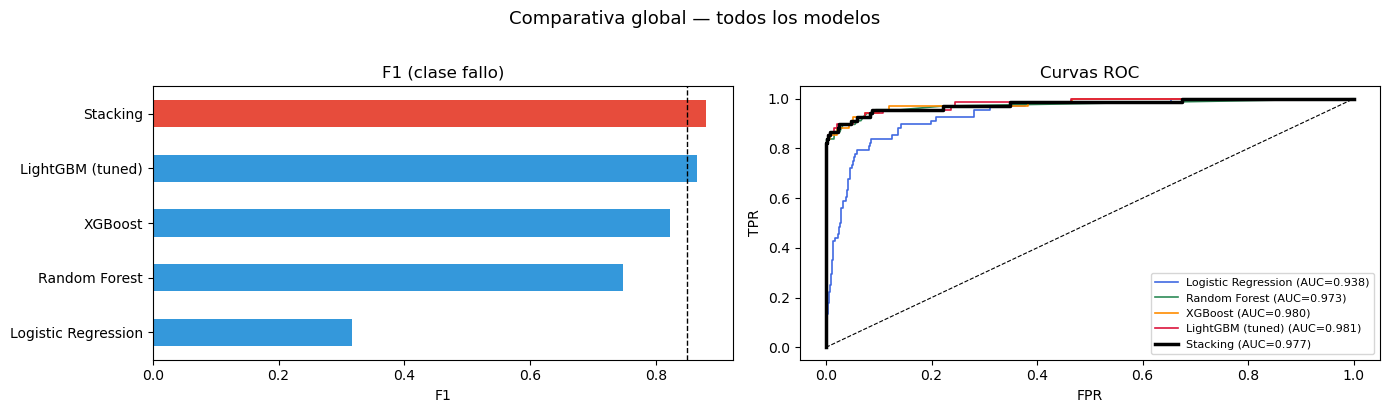

In [6]:
if 'df_comp' in dir():
    # Gráfico comparativa
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Barras F1 / AUC
    df_plot = df_comp[['F1', 'ROC-AUC']].sort_values('F1')
    colors = ['#e74c3c' if i == df_plot.index.get_loc('Stacking') else '#3498db'
              for i in range(len(df_plot))]
    df_plot['F1'].plot(kind='barh', ax=axes[0], color=[
        '#e74c3c' if i == 'Stacking' else '#3498db' for i in df_plot.index])
    axes[0].axvline(0.85, color='black', ls='--', lw=1)
    axes[0].set_title('F1 (clase fallo)')
    axes[0].set_xlabel('F1')
    
    # Curvas ROC
    ax = axes[1]
    palette = {
        'Logistic Regression': 'royalblue',
        'Random Forest':       'seagreen',
        'XGBoost':             'darkorange',
        'LightGBM (tuned)':   'crimson',
        'Stacking':            'black',
    }
    for name, row in comparativa.items():
        m_key = {'Logistic Regression': 'lr', 'Random Forest': 'rf',
                 'XGBoost': 'xgb', 'LightGBM (tuned)': 'lgbm_tuned'}.get(name)
        if m_key:
            yp = models[m_key].predict_proba(X_test)[:, 1]
        else:
            yp = y_prob_stack
        fpr, tpr, _ = roc_curve(y_test, yp)
        lw = 2.5 if name == 'Stacking' else 1.2
        ax.plot(fpr, tpr, color=palette[name], lw=lw,
                label=f"{name} (AUC={row['ROC-AUC']:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title('Curvas ROC')
    ax.legend(fontsize=8)
    
    plt.suptitle('Comparativa global — todos los modelos', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('df_comp no disponible (lgbm_tuned ausente) — omitiendo gráfico comparativa')

## 5. ¿Qué aprende el meta-modelo?

Los coeficientes de la Regresión Logística muestran el peso que da a cada base learner.


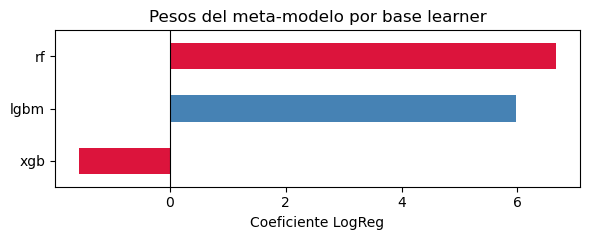

Pesos (prob fallo):
rf      6.6661
lgbm    5.9676
xgb    -1.5656


In [7]:
meta = stack.final_estimator_
n_coef = meta.coef_[0].shape[0]
# sklearn >= 1.1 pasa solo prob(clase=1) al meta-modelo → 1 columna por estimador
if n_coef == len(base_learners):
    coef_names = [name for name, _ in base_learners]
else:
    coef_names = [f'{name}_p{c}' for name, _ in base_learners for c in [0, 1]]

coef_df = pd.Series(meta.coef_[0], index=coef_names)

fig, ax = plt.subplots(figsize=(6, 2.5))
colors = ['crimson' if v > 0 else 'steelblue' for v in coef_df.values]
coef_df.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Pesos del meta-modelo por base learner')
ax.set_xlabel('Coeficiente LogReg')
plt.tight_layout()
plt.show()

print('Pesos (prob fallo):')
print(coef_df.sort_values(ascending=False).round(4).to_string())


## 5b. Diversidad de los base learners

El stacking es efectivo solo cuando los modelos cometen **errores en observaciones distintas**.
Si LGBM, XGBoost y RF fallaran siempre en los mismos casos, el ensemble no aportaría nada respecto al mejor modelo individual.

Analizamos:
1. **Correlación de probabilidades** entre base learners — baja correlación = más diversidad
2. **Solapamiento de falsos negativos** — cuántos FN comparten los tres modelos

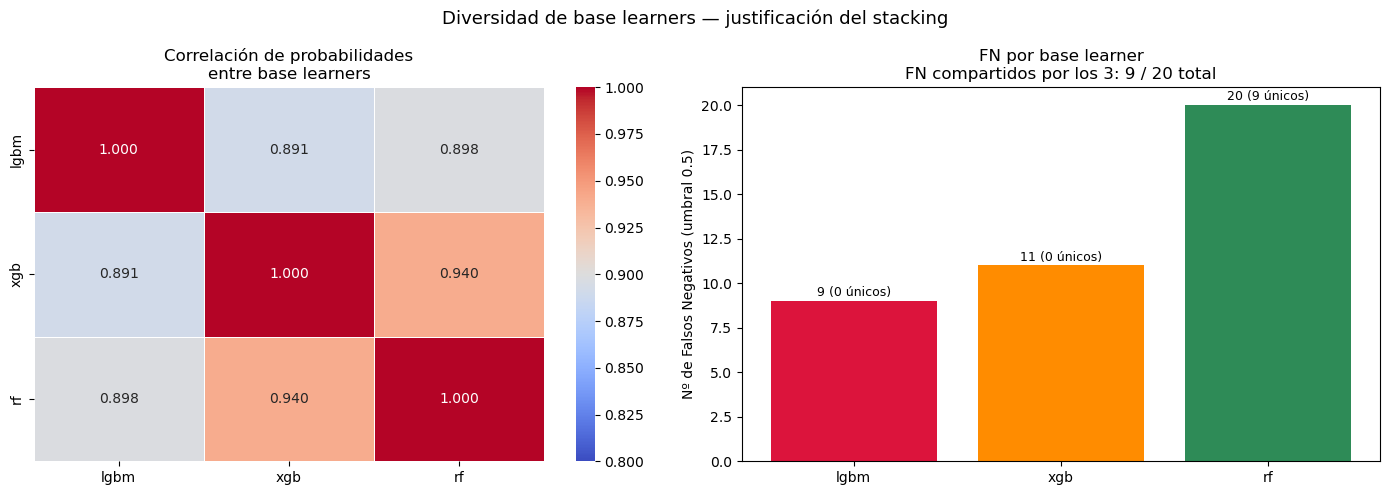

FN únicos (no vistos por los otros dos modelos):
  lgbm: 0 FN exclusivos
  xgb: 0 FN exclusivos
  rf: 9 FN exclusivos
FN compartidos por los 3: 9

→ Correlación alta en probabilidades pero FN distintos = el meta-modelo
  puede aprender a combinar los votos de forma complementaria.


In [8]:
# Probabilidades de cada base learner entrenado dentro del stacking (out-of-fold ya usadas)
# Para test usamos los modelos entrenados con todos los datos de train
probs_bl = {
    name: est.predict_proba(X_test)[:, 1]
    for name, est in stack.named_estimators_.items()
}

# ── Correlación de probabilidades entre base learners ─────────────────────────
probs_df = pd.DataFrame(probs_bl)
corr = probs_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[0],
            vmin=0.8, vmax=1.0, linewidths=0.5)
axes[0].set_title('Correlación de probabilidades\nentre base learners')

# ── Solapamiento de falsos negativos (umbral 0.5 para comparar individualmente) ─
fn_sets = {}
for name, prob in probs_bl.items():
    y_pred_bl = (prob >= 0.5).astype(int)
    fn_sets[name] = set(np.where((y_test == 1) & (y_pred_bl == 0))[0])

fn_counts = {name: len(s) for name, s in fn_sets.items()}
names_bl  = list(fn_sets.keys())

only_unique = {}
for name in names_bl:
    otros = set().union(*[fn_sets[n] for n in names_bl if n != name])
    only_unique[name] = len(fn_sets[name] - otros)

shared_all  = len(fn_sets[names_bl[0]] & fn_sets[names_bl[1]] & fn_sets[names_bl[2]])
total_union = len(fn_sets[names_bl[0]] | fn_sets[names_bl[1]] | fn_sets[names_bl[2]])

ax = axes[1]
bars = ax.bar(names_bl, [fn_counts[n] for n in names_bl],
              color=['crimson', 'darkorange', 'seagreen'])
ax.set_ylabel('Nº de Falsos Negativos (umbral 0.5)')
ax.set_title(f'FN por base learner\nFN compartidos por los 3: {shared_all} / {total_union} total')
for bar, name in zip(bars, names_bl):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{fn_counts[name]} ({only_unique[name]} únicos)",
            ha='center', va='bottom', fontsize=9)

plt.suptitle('Diversidad de base learners — justificación del stacking', fontsize=13)
plt.tight_layout()
plt.show()

print(f'FN únicos (no vistos por los otros dos modelos):')
for name in names_bl:
    print(f'  {name}: {only_unique[name]} FN exclusivos')
print(f'FN compartidos por los 3: {shared_all}')
print(f'\n→ Correlación alta en probabilidades pero FN distintos = el meta-modelo')
print('  puede aprender a combinar los votos de forma complementaria.')

## 6. Matrices de confusión — mejor modelo vs Stacking


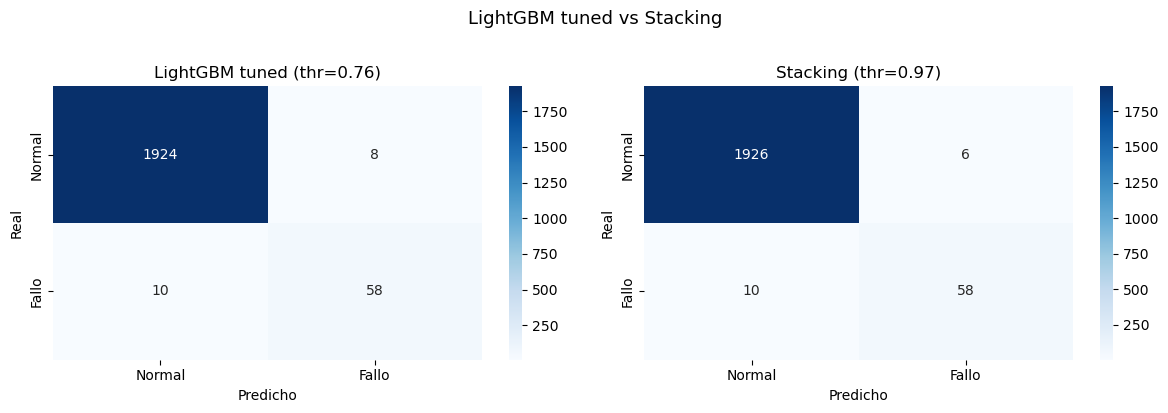

In [9]:
try:
    y_prob_lgbm = models['lgbm_tuned'].predict_proba(X_test)[:, 1]
    thr_lgbm = models['lgbm_threshold']
    y_pred_lgbm = (y_prob_lgbm >= thr_lgbm).astype(int)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, preds, title in [
        (axes[0], y_pred_lgbm,  f'LightGBM tuned (thr={thr_lgbm:.2f})'),
        (axes[1], y_pred_stack, f'Stacking (thr={thr_best:.2f})'),
    ]:
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Normal', 'Fallo'],
                    yticklabels=['Normal', 'Fallo'])
        ax.set_title(title)
        ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
    
    plt.suptitle('LightGBM tuned vs Stacking', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f'Comparativa con lgbm_tuned omitida: {{e}} no disponible')

## 7. Guardar


In [10]:
# Atomic update: reload pkl, update with new keys, save
import pickle as _pickle
_pkl = '../data/processed/models.pkl'
with open(_pkl, 'rb') as _f:
    _m = _pickle.load(_f)
_m['stacking']           = stack
_m['stacking_threshold'] = thr_best
with open(_pkl, 'wb') as _f:
    _pickle.dump(_m, _f)
print('Guardados:', ['stacking','stacking_threshold'])
print(f'Umbral stacking: {thr_best:.4f}')
print('Total keys en pkl:', len(_m))

Guardados: ['stacking', 'stacking_threshold']
Umbral stacking: 0.9688
Total keys en pkl: 18
